#### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

import joblib
import warnings
warnings.filterwarnings('ignore')

#### Load the dataset

In [2]:
df = pd.read_excel('Data_Train.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


#### Baisc Checks

In [3]:
df.shape

(10683, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [6]:
# Check for null values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
# Removing null values as they are small
df.dropna(inplace=True)

In [8]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

#### EDA

In [9]:
# Removing Redundant Columns
df = df.drop(columns=['Route','Additional_Info'],axis=1)

In [10]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,3897
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,13302


In [11]:
# Changing object cols to Date-Time 
for col in ['Date_of_Journey','Dep_Time','Arrival_Time']:
    df[col] = pd.to_datetime(df[col])

In [12]:
# Extracting day and month from (Date_of_Journey) column
df['Journey_day'] = df['Date_of_Journey'].dt.day
df['Journey_month'] = df['Date_of_Journey'].dt.month

# Removing (Date_of_Journey) column
df = df.drop('Date_of_Journey',axis=1)

In [13]:
# Extracting hours and minutes
for col in ['Dep_Time','Arrival_Time']:
    df[col +'_hours'] = df[col].dt.hour
    df[col +'_minutes'] = df[col].dt.minute
    
    # Removing columns
    df = df.drop(col,axis=1)

In [14]:
df.head()

,Airline,Source,Destination,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hours,Dep_Time_minutes,Arrival_Time_hours,Arrival_Time_minutes
0,IndiGo,Banglore,New Delhi,2h 50m,non-stop,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2 stops,7662,5,1,5,50,13,15
2,Jet Airways,Delhi,Cochin,19h,2 stops,13882,6,9,9,25,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1 stop,6218,5,12,18,5,23,30
4,IndiGo,Banglore,New Delhi,4h 45m,1 stop,13302,3,1,16,50,21,35


In [15]:
# Separating Duration hours and minutes
duration = list(df['Duration'])
for i in range(len(duration)):
    if len(duration[i].split(' ')) == 2:
        pass
    else:
        if 'h' in duration[i]:
            duration[i] = duration[i] + ' 0m'
        else:
            duration[i]='0h ' + duration[i]

In [16]:
df['Duration'] = duration

In [17]:
df.head()

,Airline,Source,Destination,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hours,Dep_Time_minutes,Arrival_Time_hours,Arrival_Time_minutes
0,IndiGo,Banglore,New Delhi,2h 50m,non-stop,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2 stops,7662,5,1,5,50,13,15
2,Jet Airways,Delhi,Cochin,19h 0m,2 stops,13882,6,9,9,25,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1 stop,6218,5,12,18,5,23,30
4,IndiGo,Banglore,New Delhi,4h 45m,1 stop,13302,3,1,16,50,21,35


In [18]:
# Applying  hour and minute condition
def hour(x):
    return x.split(' ')[0][0:-1] 

def minutes(x):
    return x.split(' ')[1][0:-1] 

In [19]:
# Extracting columns from Duration and changing datatype
df['Dur_hour'] = df['Duration'].apply(hour).astype(int)
df['Dur_min'] = df['Duration'].apply(minutes).astype(int)

# Removing Duration column
df = df.drop('Duration',axis=1)

In [20]:
df.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hours,Dep_Time_minutes,Arrival_Time_hours,Arrival_Time_minutes,Dur_hour,Dur_min
0,IndiGo,Banglore,New Delhi,non-stop,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2 stops,7662,5,1,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2 stops,13882,6,9,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1 stop,6218,5,12,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1 stop,13302,3,1,16,50,21,35,4,45


In [21]:
# Stats summary of numerical features
df.describe()

,Price,Journey_day,Journey_month,Dep_Time_hours,Dep_Time_minutes,Arrival_Time_hours,Arrival_Time_minutes,Dur_hour,Dur_min
count,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000
mean,9087.214567,12.682925,5.534731,12.491013,24.409287,13.349186,24.690601,10.244898,28.326624
std,4611.548810,8.803800,2.987626,5.748820,18.767801,6.859317,16.506808,8.494916,16.945817
min,1759.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5277.000000,5.000000,3.000000,8.000000,5.000000,8.000000,10.000000,2.000000,15.000000
50%,8372.000000,6.000000,5.000000,11.000000,25.000000,14.000000,25.000000,8.000000,30.000000
75%,12373.000000,21.000000,6.000000,18.000000,40.000000,19.000000,35.000000,15.000000,45.000000
max,79512.000000,27.000000,12.000000,23.000000,55.000000,23.000000,55.000000,47.000000,55.000000


In [22]:
# Stats summary of categorical features
df.describe(include='O')

,Airline,Source,Destination,Total_Stops
count,10682,10682,10682,10682
unique,12,5,6,5
top,Jet Airways,Delhi,Cochin,1 stop
freq,3849,4536,4536,5625


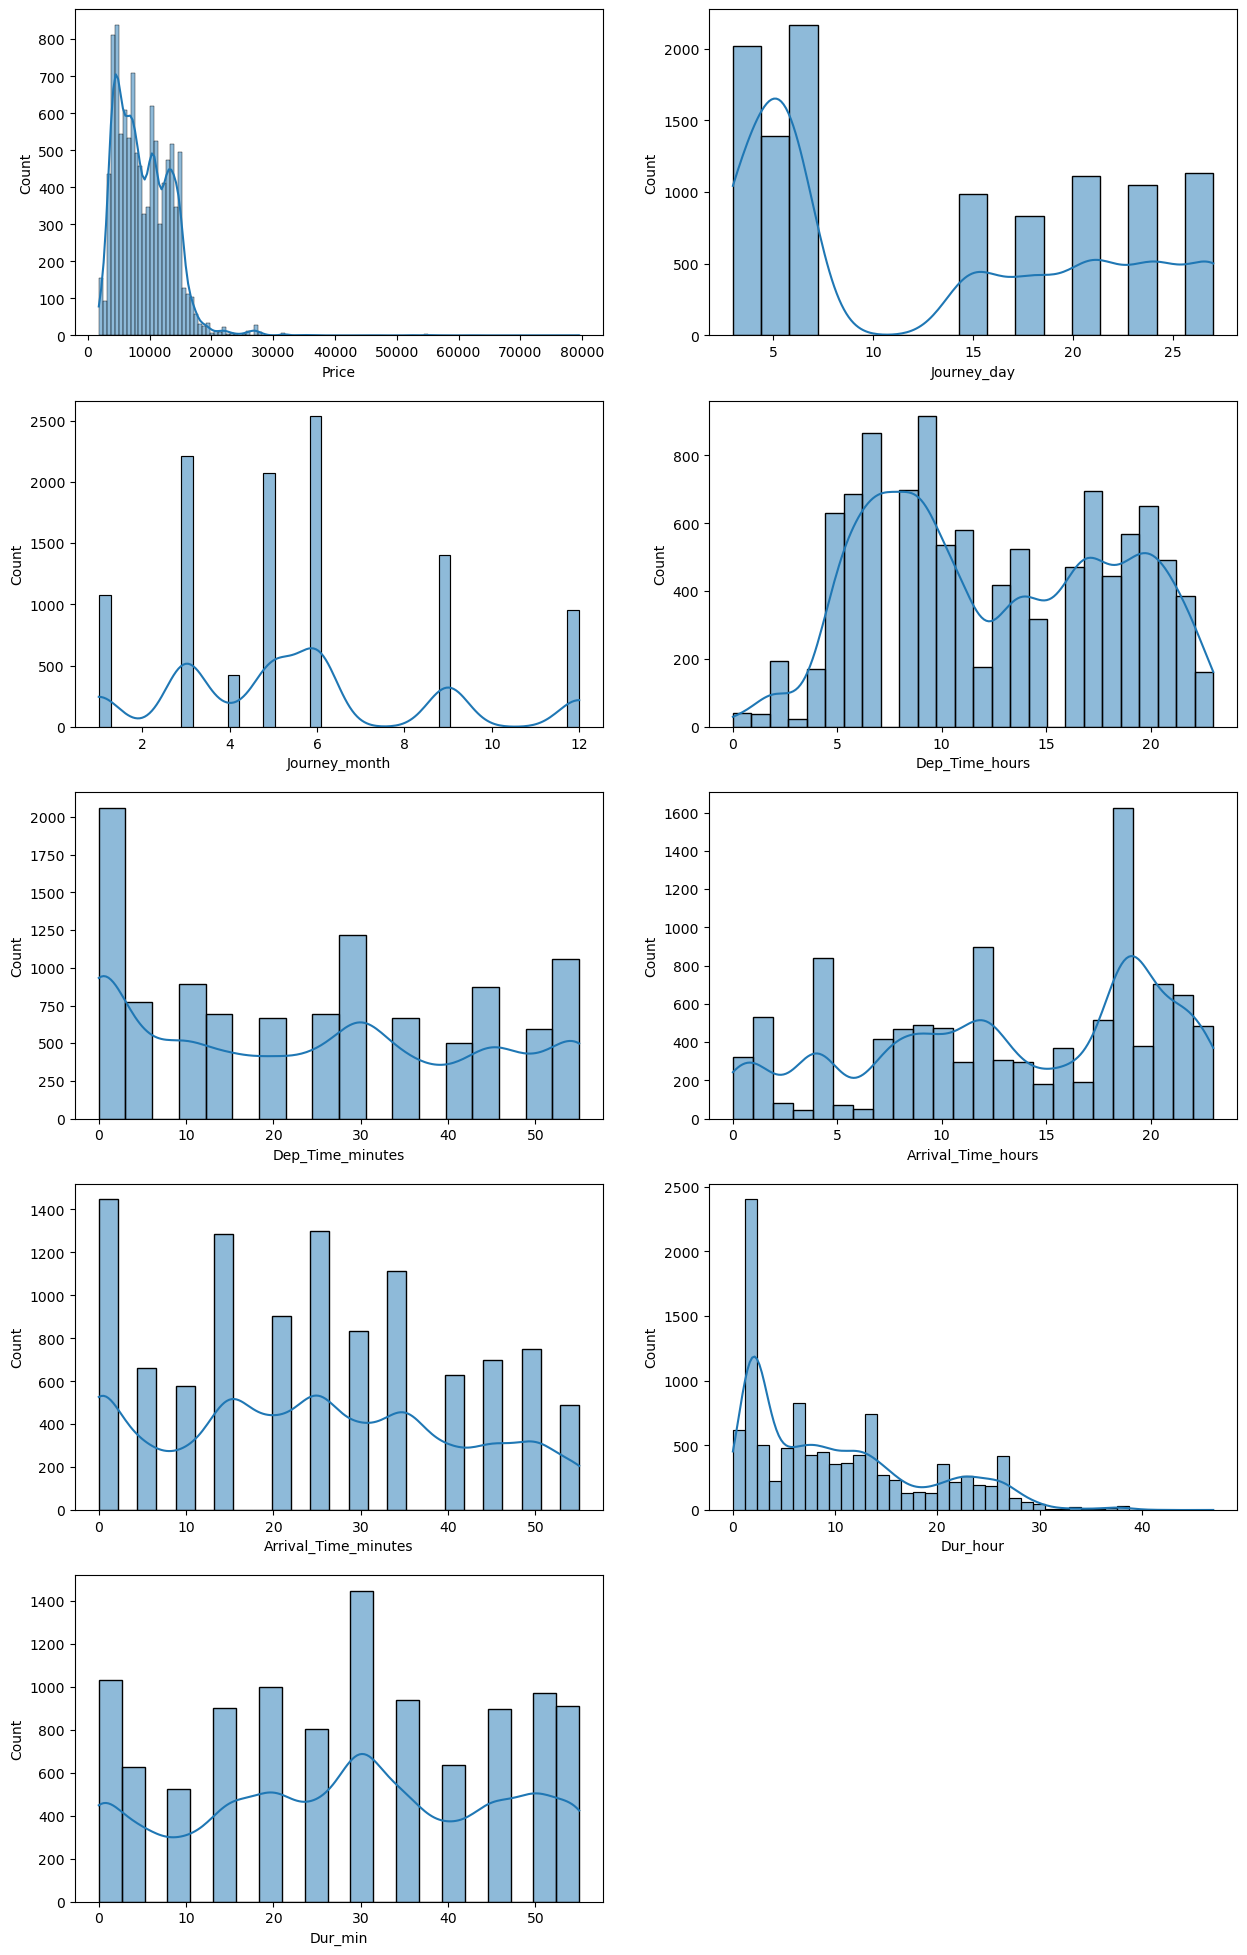

In [23]:
# Distribution of numerical columns
num_cols = [col for col in  df.columns if df[col].dtype != 'object']
plt.figure(figsize=(15,50))
for i,col in enumerate(num_cols):
    plt.subplot(10,2,i+1)
    sns.histplot(x=df[col],kde=True)
plt.show()

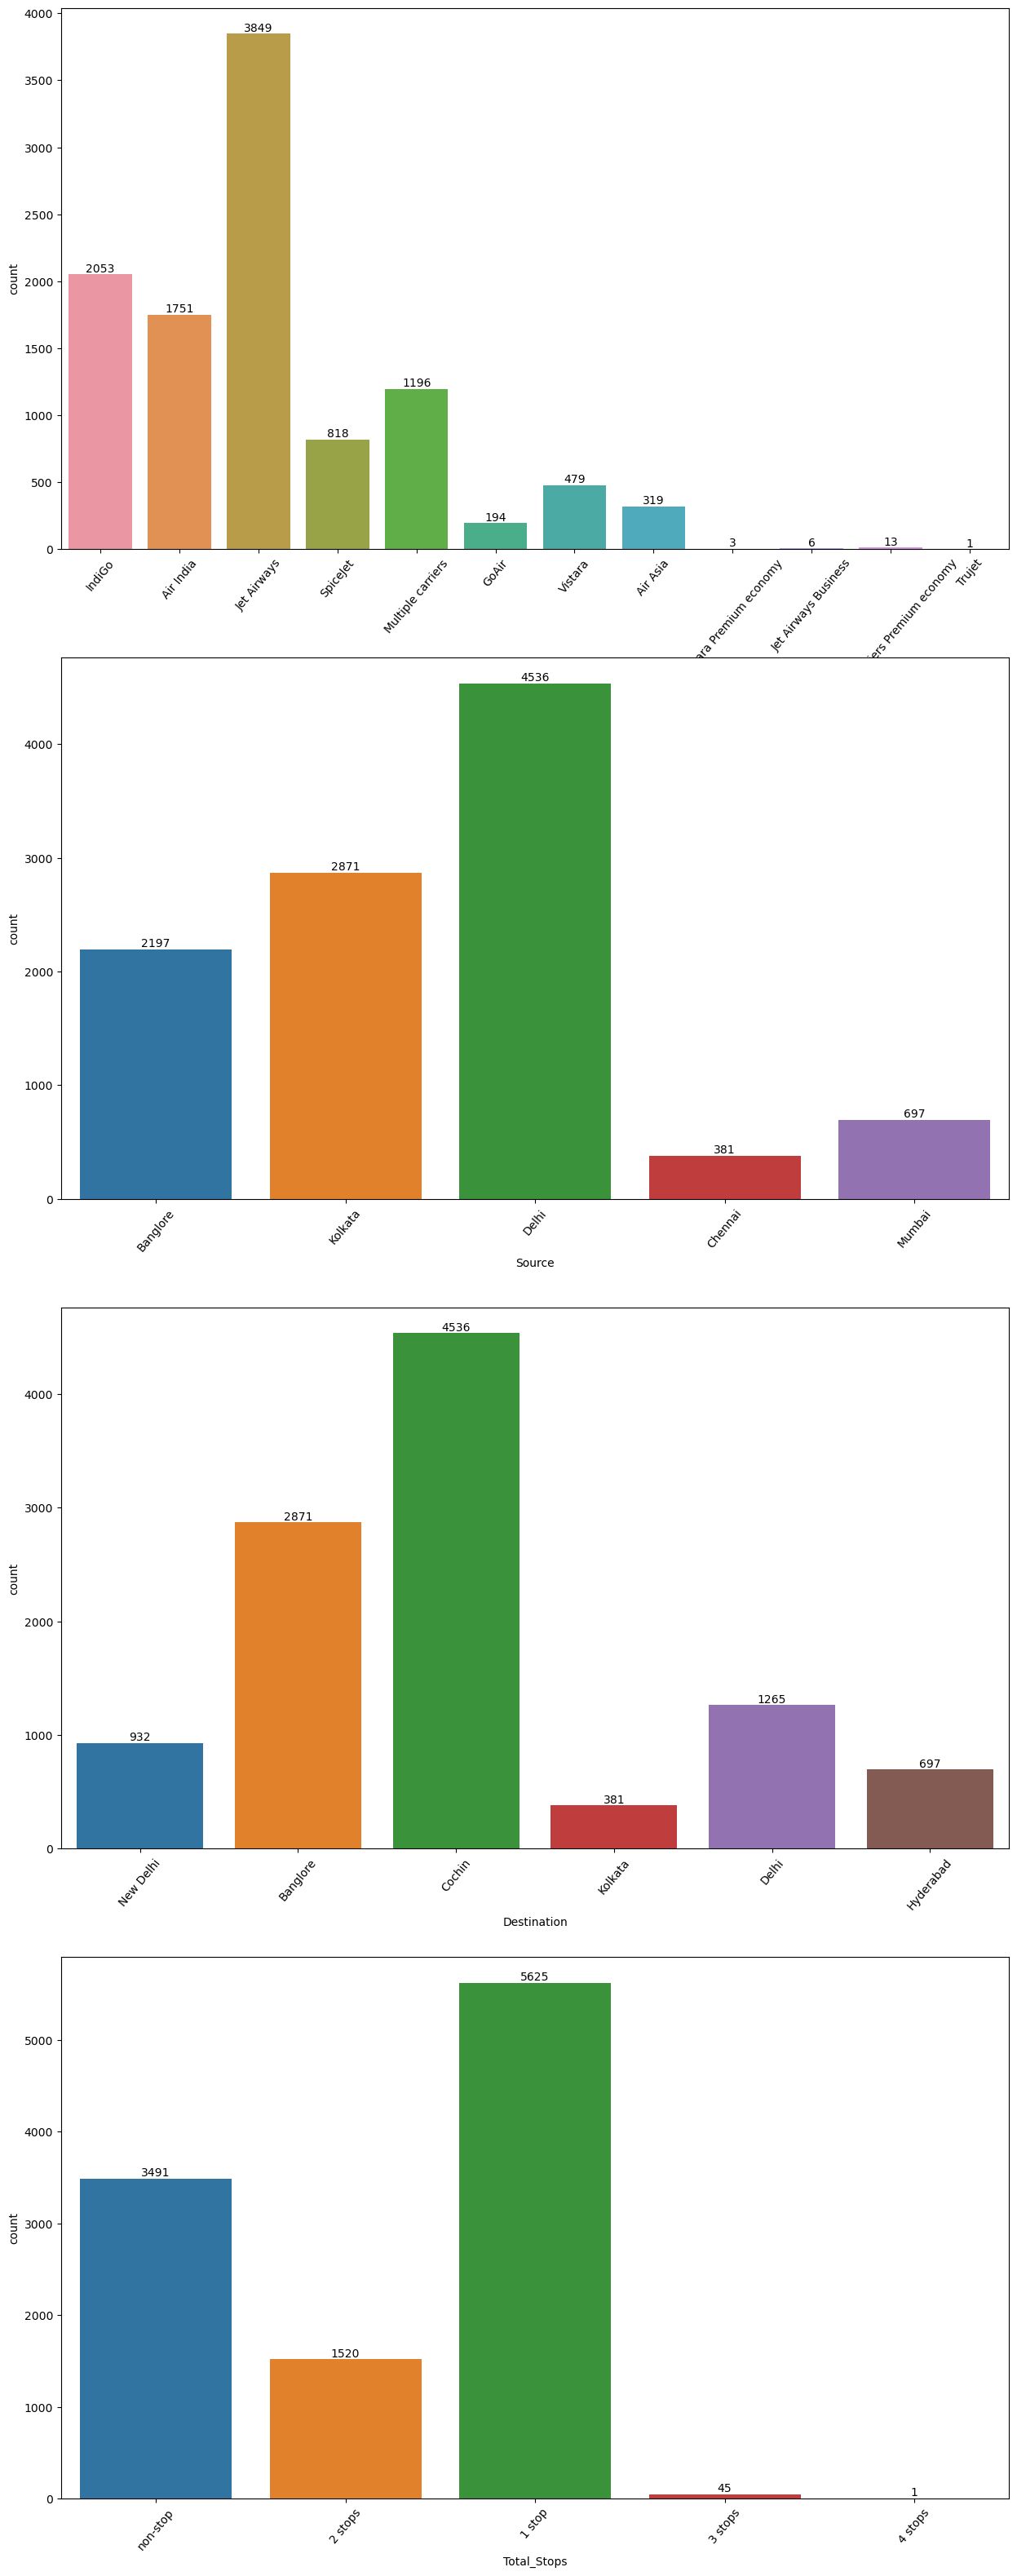

In [24]:
# Distribution of Category columns
cat_cols = ['Airline','Source','Destination','Total_Stops']
plt.figure(figsize=(15,50))
for i,col in enumerate(cat_cols):
    plt.subplot(5,1,i+1)
    ax = sns.countplot(x=df[col],data=df)
    ax.bar_label(ax.containers[0])
    plt.xticks(rotation=(50))

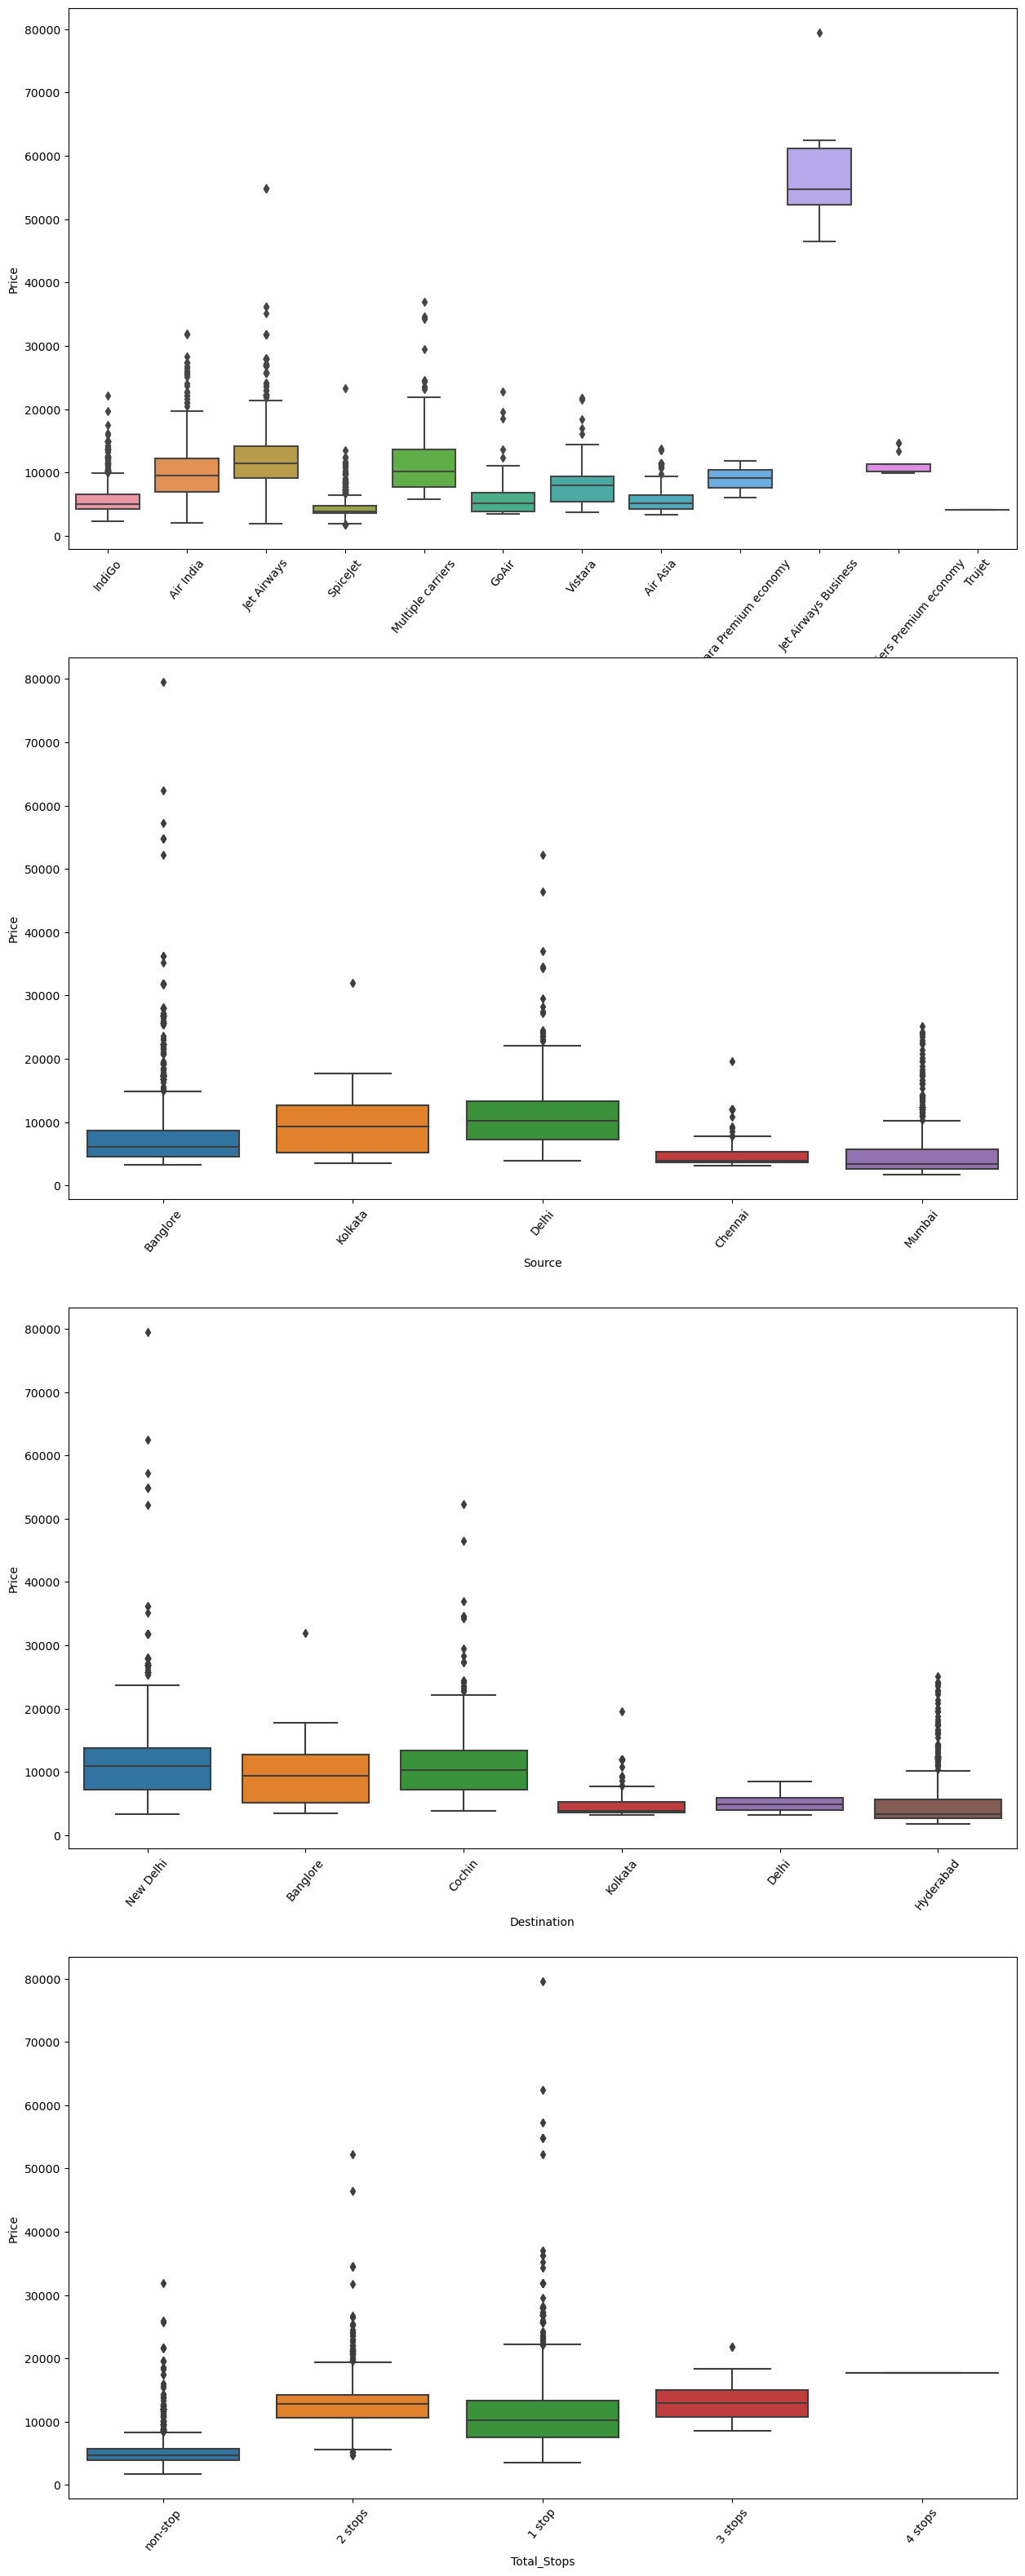

In [25]:
# Relationship between categorical features and Price
plt.figure(figsize=(15,50))
for i,col in enumerate(cat_cols):
    plt.subplot(5,1,i+1)
    sns.boxplot(x=df[col],y='Price',data=df.sort_values('Price',ascending=False))
    plt.xticks(rotation=(50))

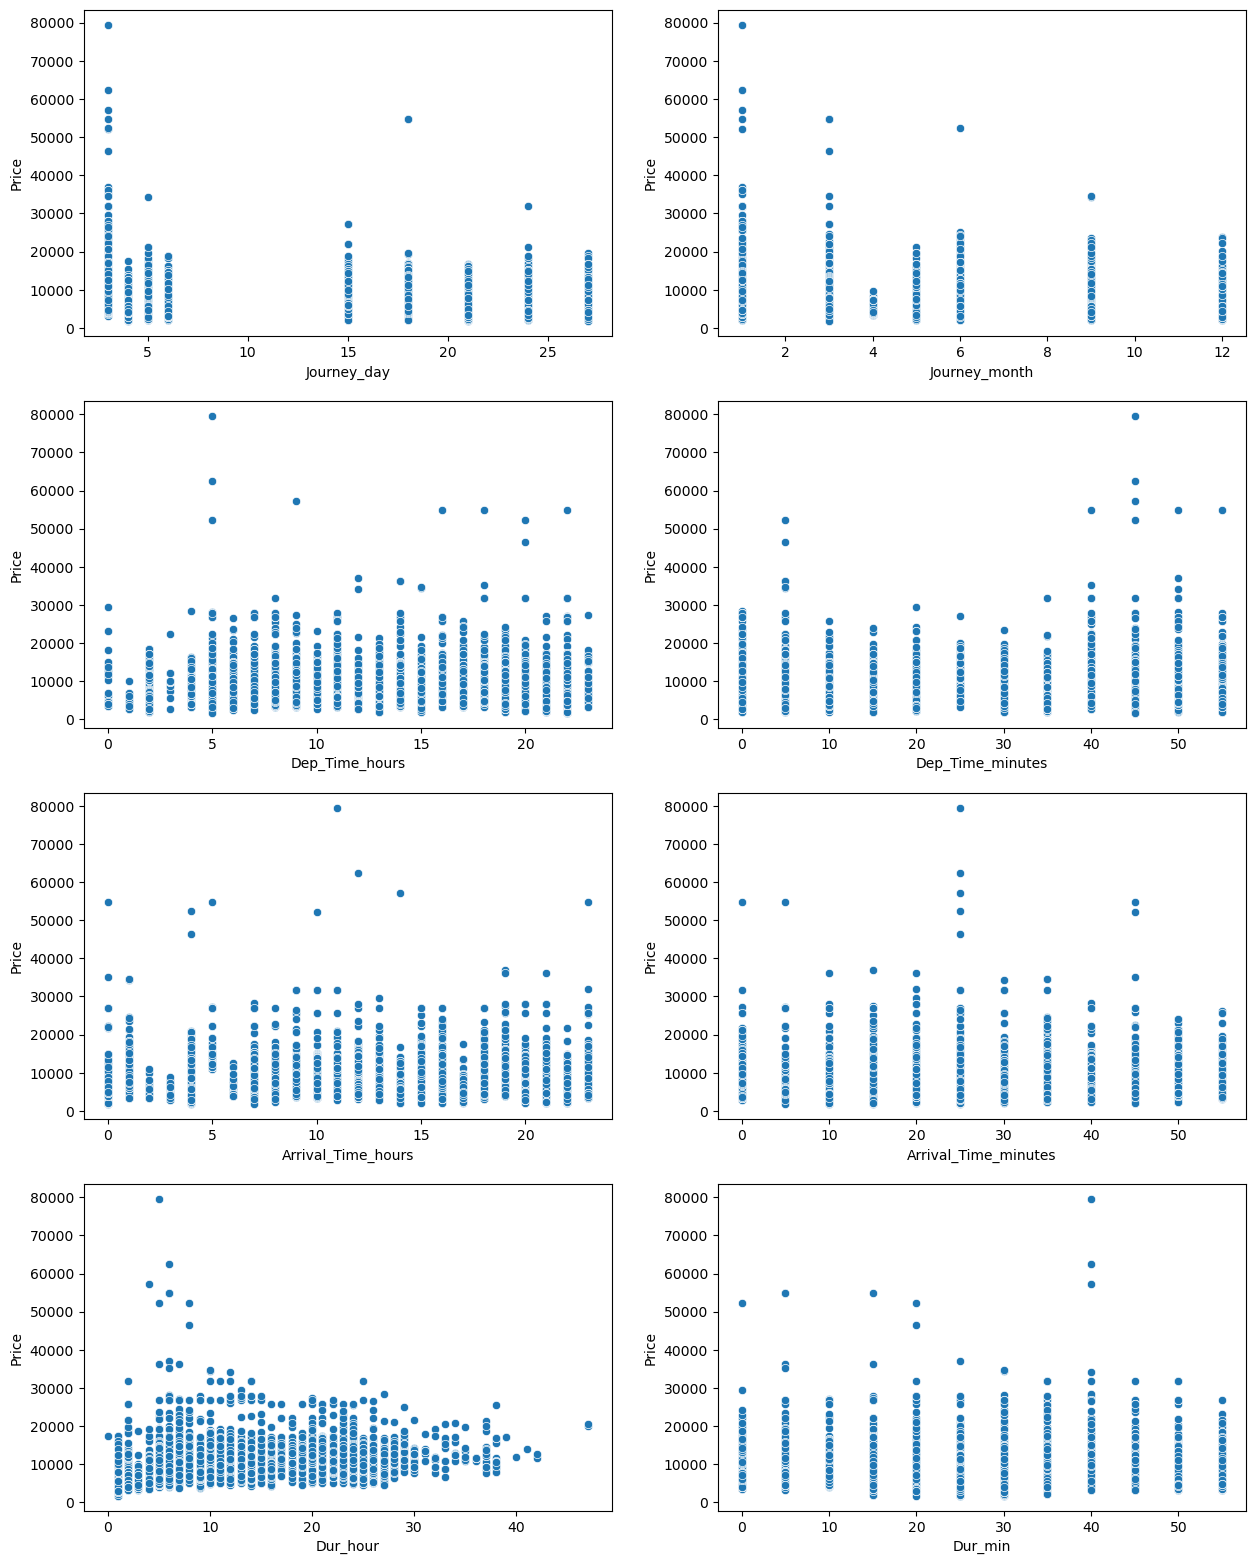

In [26]:
# Relationship between numerical features and Price
columns = ['Journey_day','Journey_month','Dep_Time_hours','Dep_Time_minutes','Arrival_Time_hours','Arrival_Time_minutes','Dur_hour','Dur_min']
plt.figure(figsize=(15,50))
for i,col in enumerate(columns):
    plt.subplot(10,2,i+1)
    sns.scatterplot(x=df[col],y=df['Price'])

<Axes: xlabel='Total_Stops', ylabel='Dur_hour'>

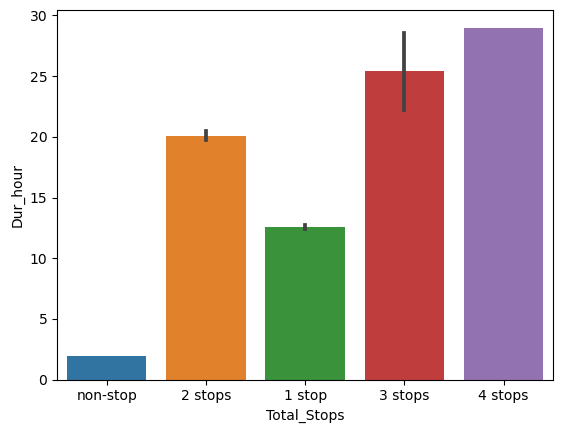

In [27]:
# Relationship between total_stops and dur_hour
sns.barplot(x=df['Total_Stops'],y=df['Dur_hour'])

<Axes: xlabel='count', ylabel='Airline'>

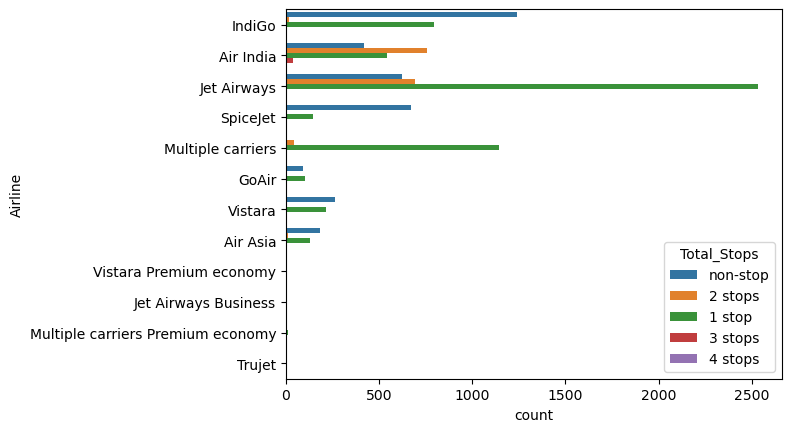

In [28]:
# Relationship between total_stops and airline
sns.countplot(data=df, y='Airline', hue='Total_Stops')

<Axes: xlabel='Source', ylabel='count'>

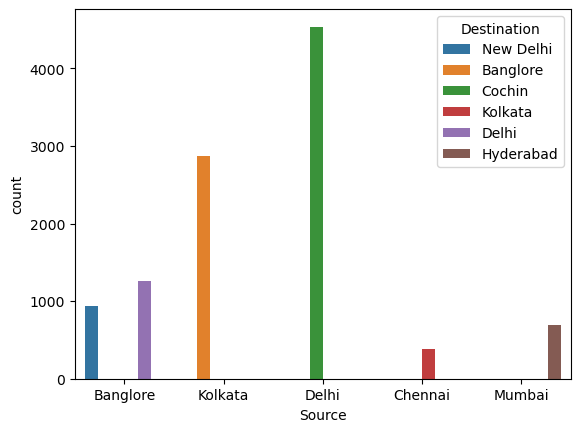

In [29]:
# Relationship between source and destination
sns.countplot(data=df, x='Source', hue='Destination')

<Axes: >

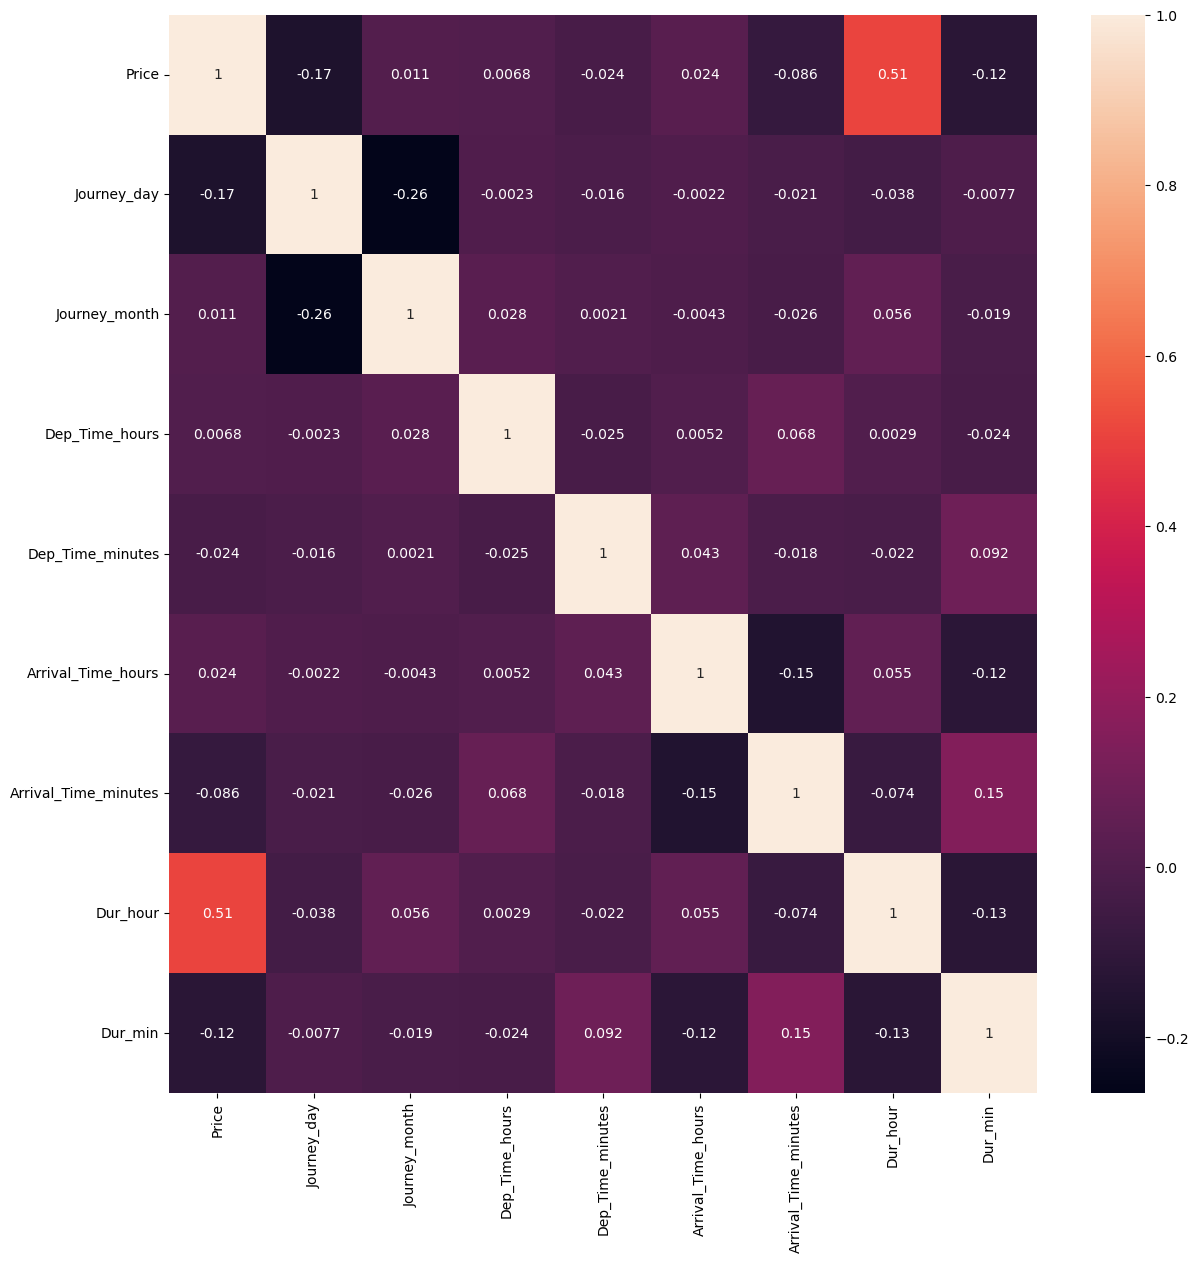

In [30]:
# Correlation heatmap
plt.figure(figsize=(14,14))
sns.heatmap(data=df.corr(),annot=True)

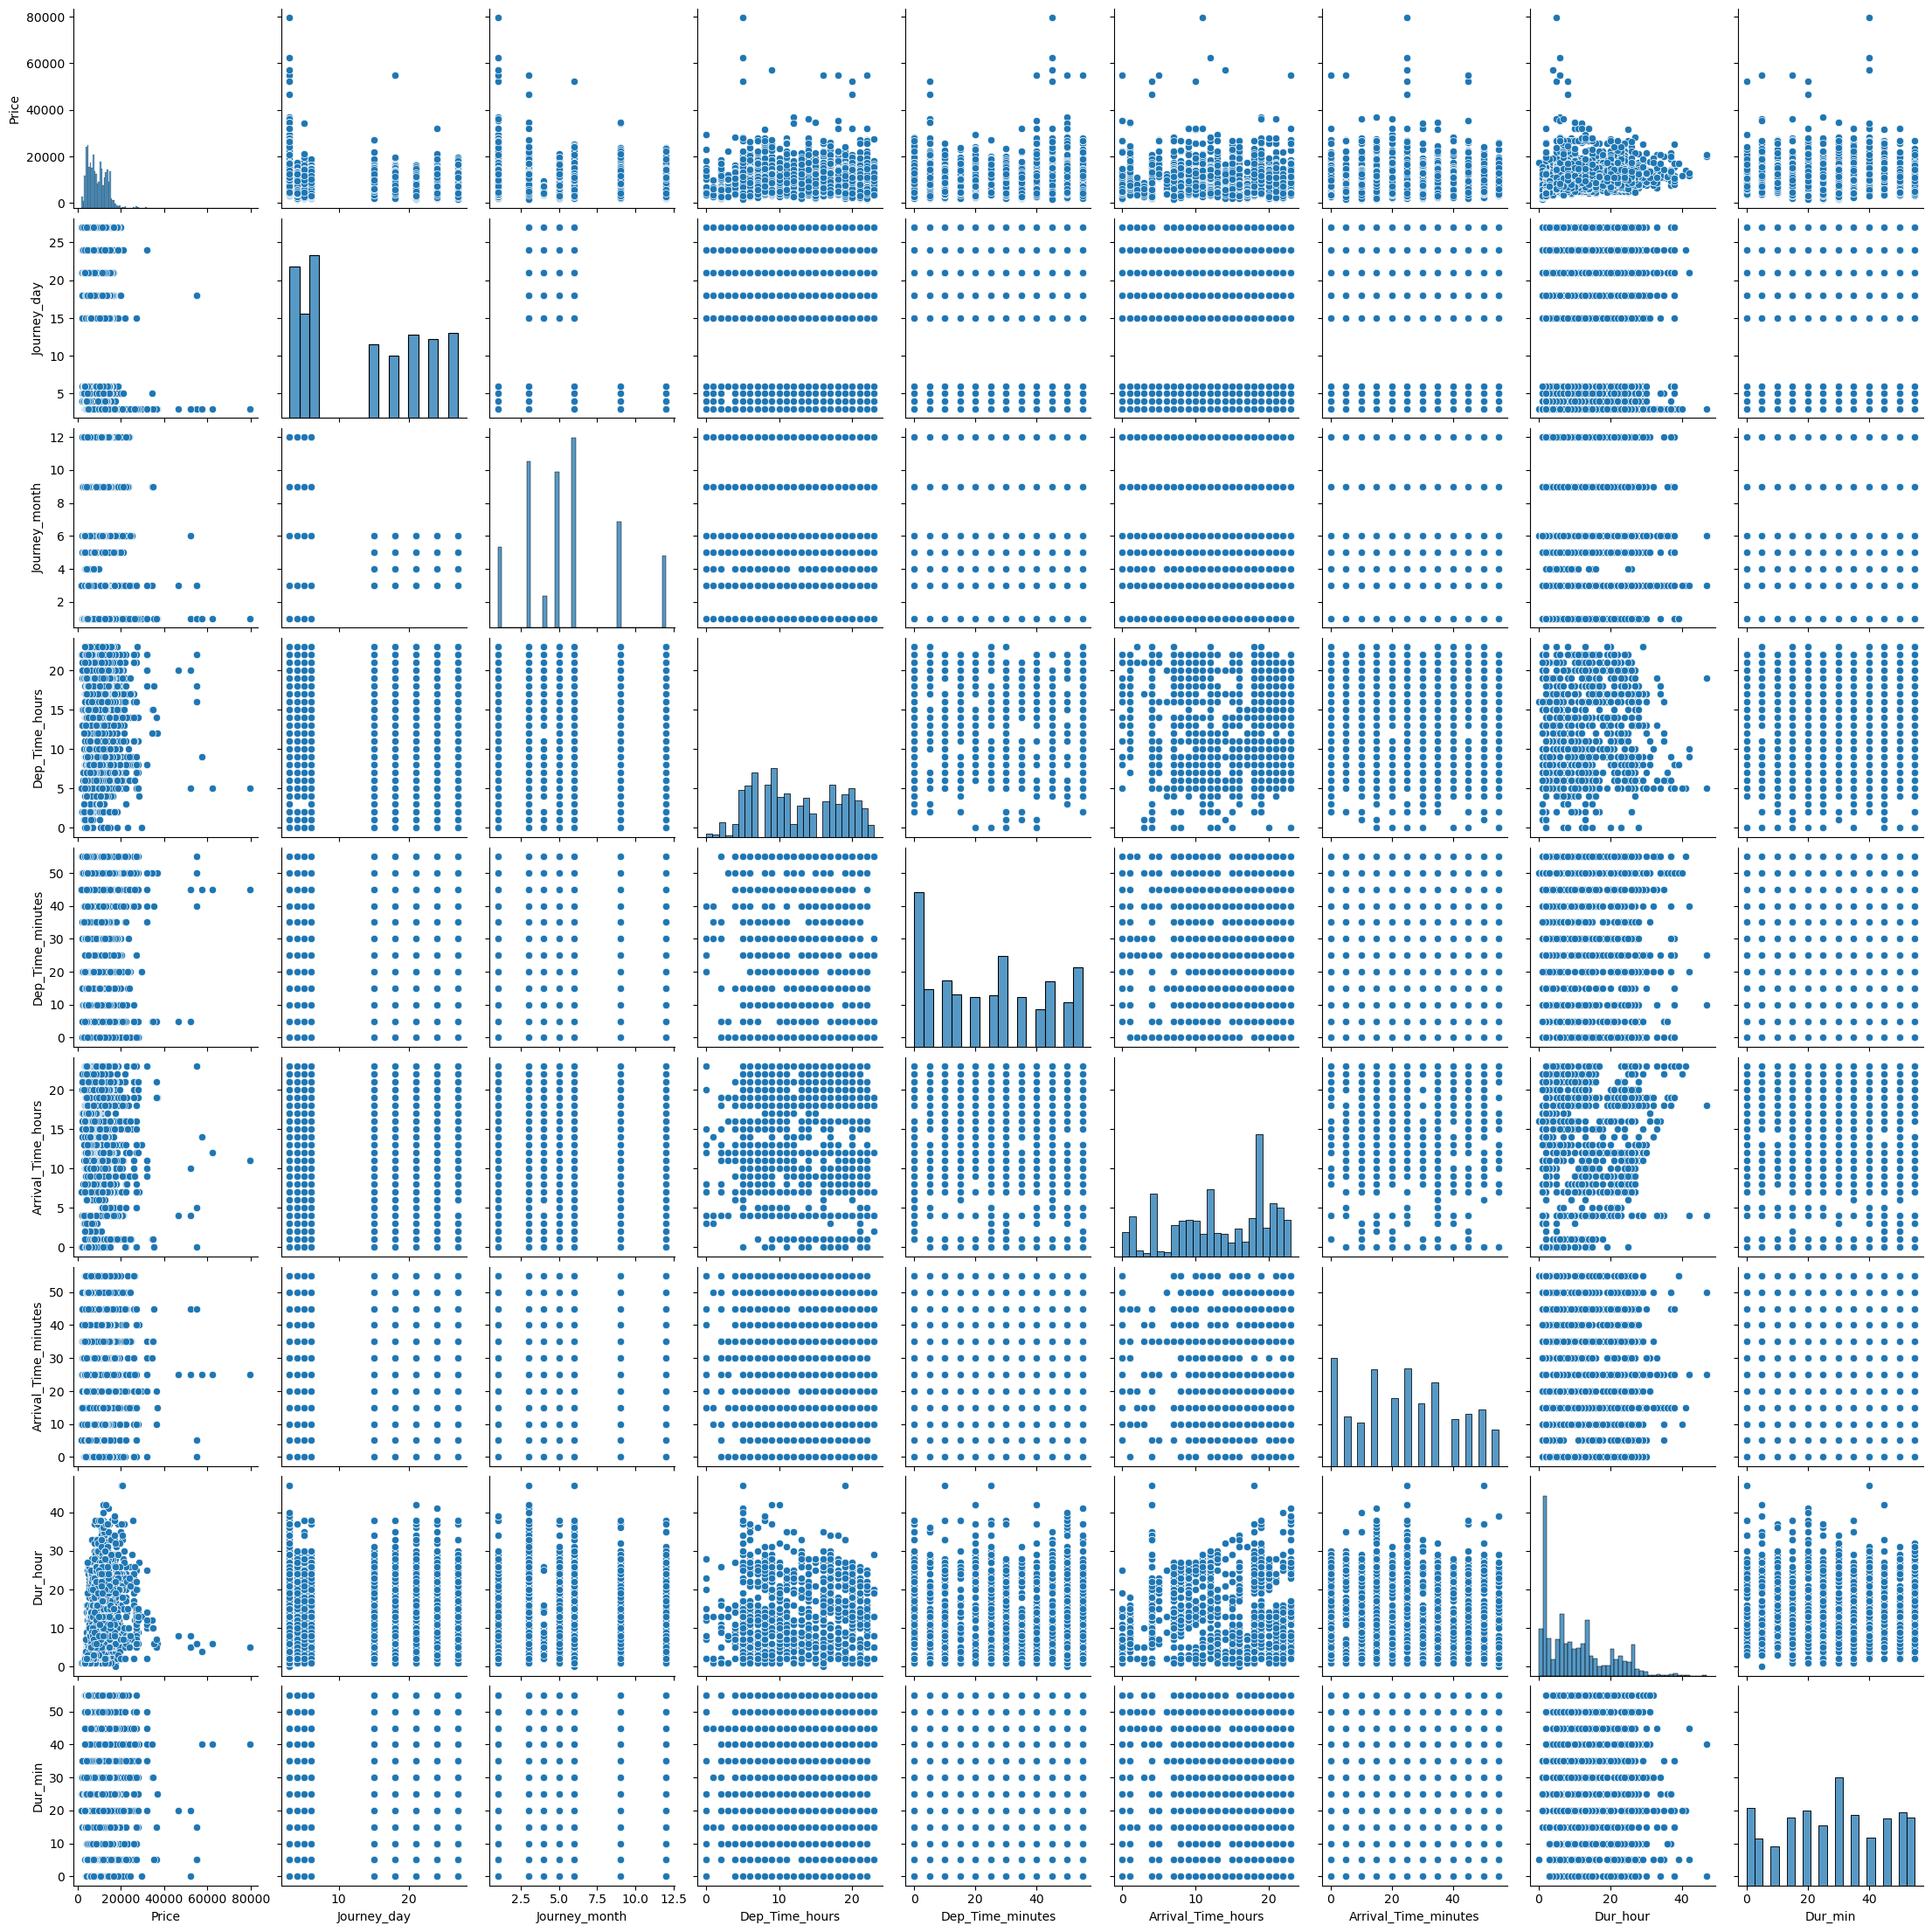

In [31]:
sns.pairplot(data=df)
plt.show()

<Axes: >

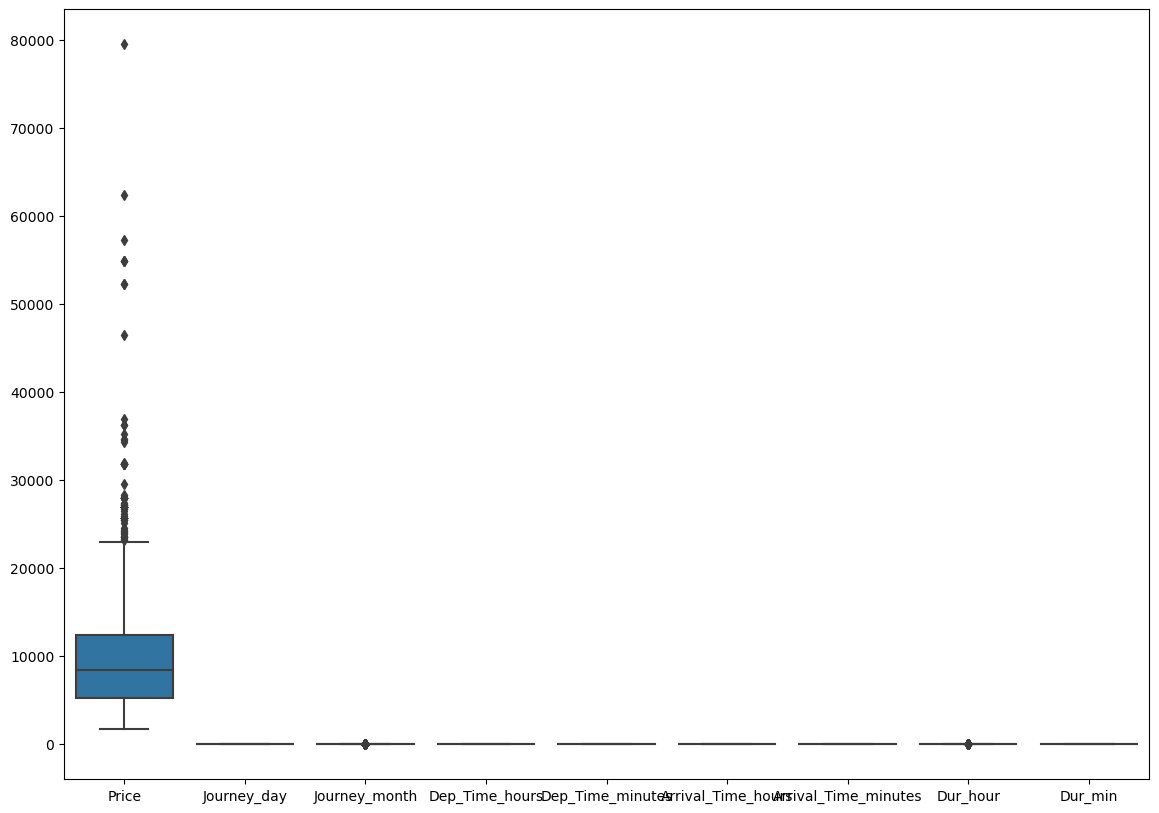

In [32]:
# Check for outliers
plt.figure(figsize=(14,10))
sns.boxplot(data=df)

#### Data Preprocessing

##### Encoding
- Nominal Data >> One hot Encoding
- Ordinal Data >> Label Encoding

In [33]:
Airline = df[['Airline']]
Airline = pd.get_dummies(Airline,drop_first=True)
Airline.head()

,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0


In [34]:
Source = df[['Source']]
Source = pd.get_dummies(Source,drop_first=True)
Source.head()

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,0,1,0
4,0,0,0,0


In [35]:
Destination = df[['Destination']]
Destination = pd.get_dummies(Destination,drop_first=True)
Destination.head()

,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,0,0,0,1
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1


In [36]:
# Total Stops column
dict = {'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}
df['Total_Stops'] = df['Total_Stops'].map(dict)

In [37]:
# Dropping columns
df = df.drop(columns=['Airline','Source','Destination'],axis=1)

In [38]:
df.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hours,Dep_Time_minutes,Arrival_Time_hours,Arrival_Time_minutes,Dur_hour,Dur_min
0,0,3897,24,3,22,20,1,10,2,50
1,2,7662,5,1,5,50,13,15,7,25
2,2,13882,6,9,9,25,4,25,19,0
3,1,6218,5,12,18,5,23,30,5,25
4,1,13302,3,1,16,50,21,35,4,45


In [39]:
# Combining encoded data to df
final_df = pd.concat([df,Airline,Source,Destination],axis=1)

In [40]:
final_df.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hours,Dep_Time_minutes,Arrival_Time_hours,Arrival_Time_minutes,Dur_hour,Dur_min,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,5,1,5,50,13,15,7,25,...,0,0,0,1,0,0,0,0,0,0
2,2,13882,6,9,9,25,4,25,19,0,...,0,0,1,0,0,1,0,0,0,0
3,1,6218,5,12,18,5,23,30,5,25,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,3,1,16,50,21,35,4,45,...,0,0,0,0,0,0,0,0,0,1


In [41]:
final_df.shape

(10682, 30)

In [42]:
# Feature Separation
X = final_df.drop('Price',axis=1)
y = final_df.Price

In [43]:
# Splitting the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [44]:
X_train.shape

(8545, 29)

In [45]:
X_test.shape

(2137, 29)

#### Model Training

In [46]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train,y_train)

RandomForestRegressor()

In [47]:
train_score = rf_model.score(X_train,y_train)
y_pred = rf_model.predict(X_test)

In [48]:
print('Training R2 Score:',train_score)

Training R2 Score: 0.9550889614995176


In [49]:
print('Testing R2 Score:',r2_score(y_test,y_pred))
print('MAE:',mean_absolute_error(y_test, y_pred))
print('MSE:',mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

Testing R2 Score: 0.7962934850399245
MAE: 1266.3928141624144
MSE: 4779601.602721009
RMSE: 2186.229997672022


#### Hyperparameter Tuning with RandomizedSearchCV

In [50]:
# Parameters
n_estimators = [int(x) for x in np.linspace(100,1200,12)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(5,30,6)]
min_samples_split = [2, 5, 10, 15, 100]
min_samples_leaf = [1, 2, 5, 10]

In [51]:
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

In [52]:
rf_random = RandomizedSearchCV(estimator = rf_model, param_distributions = random_grid,scoring='neg_mean_squared_error', n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = 1)

In [53]:
rf_random.fit(X_train,y_train)
print('Best Parameters:',rf_random.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   8.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   8.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   8.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   8.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   8.8s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=  13.6s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=  13.6s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimator

#### Model Evaluation

In [54]:
tuned_model = rf_random.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

In [55]:
print('Tuned Model R2 Score:',r2_score(y_test,y_pred_tuned))
print('Tuned Model MAE:',mean_absolute_error(y_test,y_pred_tuned))
print('Tuned Model MSE:',mean_squared_error(y_test,y_pred_tuned))
print('Tuned Model RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_tuned)))

Tuned Model R2 Score: 0.8130473283162933
Tuned Model MAE: 1217.925401707814
Tuned Model MSE: 4386503.246533612
Tuned Model RMSE: 2094.398063056212


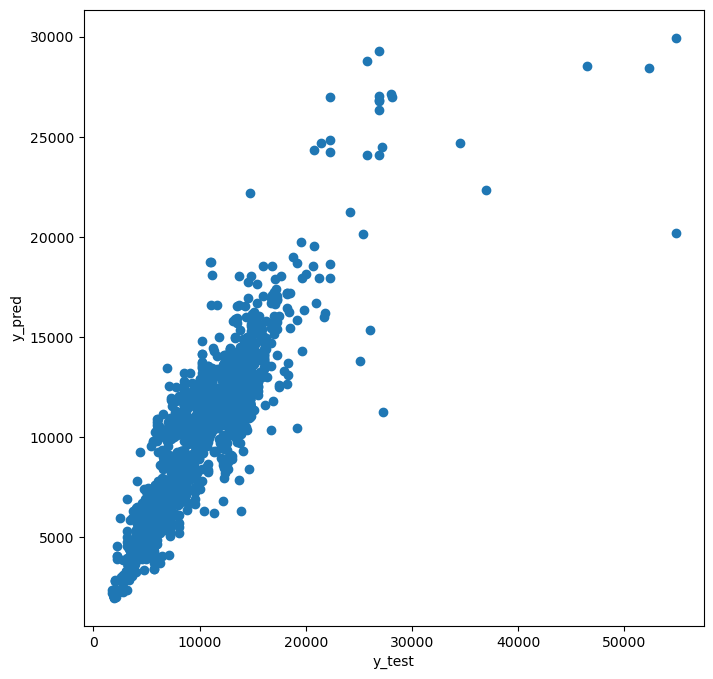

In [56]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize = (8,8))
plt.scatter(y_test, y_pred_tuned)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

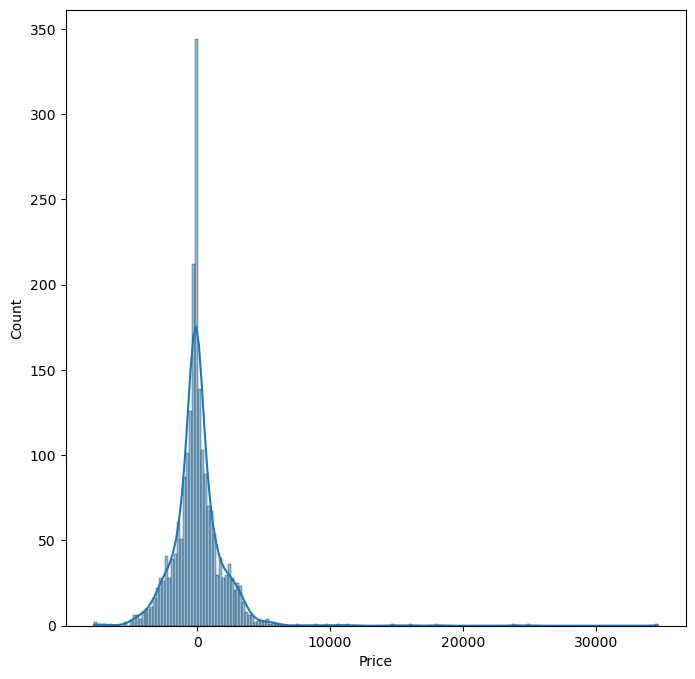

In [57]:
# Distribution of Residuals
plt.figure(figsize = (8,8))
sns.histplot(y_test-y_pred_tuned,kde=True)
plt.show()

#### Saving the model and reuse it again

In [60]:
# Save the model
joblib.dump(tuned_model,'flight_model.pkl')

['flight_model.pkl']

In [61]:
# Load the model
model = joblib.load('flight_model.pkl')

In [62]:
y_pred  = model.predict(X_test)

In [63]:
r2_score(y_test, y_pred_tuned)

0.8130473283162933